# DSCI 506 — Time Series Analysis & Forecasting
## Homework 1: Foundations of Time Series
**Student:** Ahmad Naggayev  
**Weeks:** 1–4 | Components · Data Processing · Smoothing · Decomposition  
**Points:** 100

In [1]:
# ── Setup: generate store_sales.csv ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from statsmodels.tsa.seasonal import seasonal_decompose, STL

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

rng = np.random.default_rng(506)
idx = pd.date_range('2015-01-01', periods=120, freq='MS')
t = np.arange(120)
trend = 200 + 1.6 * t
season = 1 + 0.25 * np.sin(2 * np.pi * (t % 12) / 12) + 0.12 * np.cos(2 * np.pi * (t % 12) / 6)
noise = rng.normal(0, 0.04, 120)
sales = np.round(trend * season * (1 + noise), 1)
df_raw = pd.DataFrame({'date': idx, 'sales': sales})
df_raw.loc[17, 'sales'] = np.nan   # 2016-06 missing
df_raw.loc[58, 'sales'] = np.nan   # 2019-11 missing
df_raw.loc[59, 'sales'] = np.nan   # 2019-12 missing
df_raw.loc[83, 'sales'] = 9999.9   # 2021-12 data-entry error
df_raw.to_csv('store_sales.csv', index=False)
print('store_sales.csv created:', df_raw.shape)
df_raw.head(3)

store_sales.csv created: (120, 2)


,date,sales
0,2015-01-01,226.3
1,2015-02-01,236.3
2,2015-03-01,241.2


---
## Part A — Week 1: Introduction & Time-Series Components (20 pts)

### A1. Vocabulary with Teeth (5 pts) — by-hand

**Level:** The baseline value of the series at a given point in time — the "average" around which fluctuations occur. Example: daily electricity demand for a city; the baseline megawatt consumption in a mild-weather month represents the level.

**Trend:** A long-run, persistent increase or decrease in the level of the series over time. Example: global average temperature anomalies since 1880 — a clear upward trend driven by warming.

**Seasonality:** A regular, repeating pattern tied to the calendar — fixed period, predictable timing. Example: monthly retail sales with a December spike every year without fail.

**Cyclic behavior:** Rises and falls that repeat but with no fixed period — driven by economic or business cycles, not the calendar. Example: U.S. GDP growth over multi-year expansion/recession cycles; the duration of each cycle varies.

**Noise (irregular):** The random, unpredictable residual left after removing trend, seasonality, and cycle — pure randomness with no structure. Example: a single day's stock price movement; no component explains it after all systematic structure is removed.

---

**Additive model:** $y_t = T_t + S_t + C_t + E_t$

**Multiplicative model:** $y_t = T_t \times S_t \times C_t \times E_t$

**Key distinguishing assumption:** The additive model assumes the seasonal and irregular fluctuations are *constant in absolute size* regardless of the level; the multiplicative model assumes they scale *proportionally* with the level — so a rising trend makes the seasonal swings grow too.

### A2. Seasonal vs. Cyclical (5 pts) — by-hand

**Key test:** Is the period fixed and calendar-linked? → Seasonal. Variable and driven by external forces? → Cyclical.

1. **Monthly retail sales peaking every December** → **Seasonal.** Period is exactly 12 months, calendar-linked (holiday shopping).

2. **U.S. unemployment over 40 years** → **Cyclical.** Driven by business cycle expansions/recessions; each cycle lasts 2–10 years with no fixed length.

3. **Daily electricity demand rising on hot afternoons** → **Seasonal** (sub-daily/daily). Period is 24 hours, driven by consistent human daily activity patterns.

4. **Sunspot counts (~11-year cycles)** → **Cyclical.** The ~11-year period is approximate and variable — it is not calendar-linked and each cycle's length drifts.

5. **Quarterly ice-cream revenue** → **Seasonal.** Summer peaks repeat every 4 quarters with a fixed annual calendar rhythm.

6. **A stock's daily closing price** → **Neither.** Stock prices are predominantly noise (random walk); no consistent seasonal or cyclical structure dominates.

### A3. First Contact with the Data (6 pts) — coding

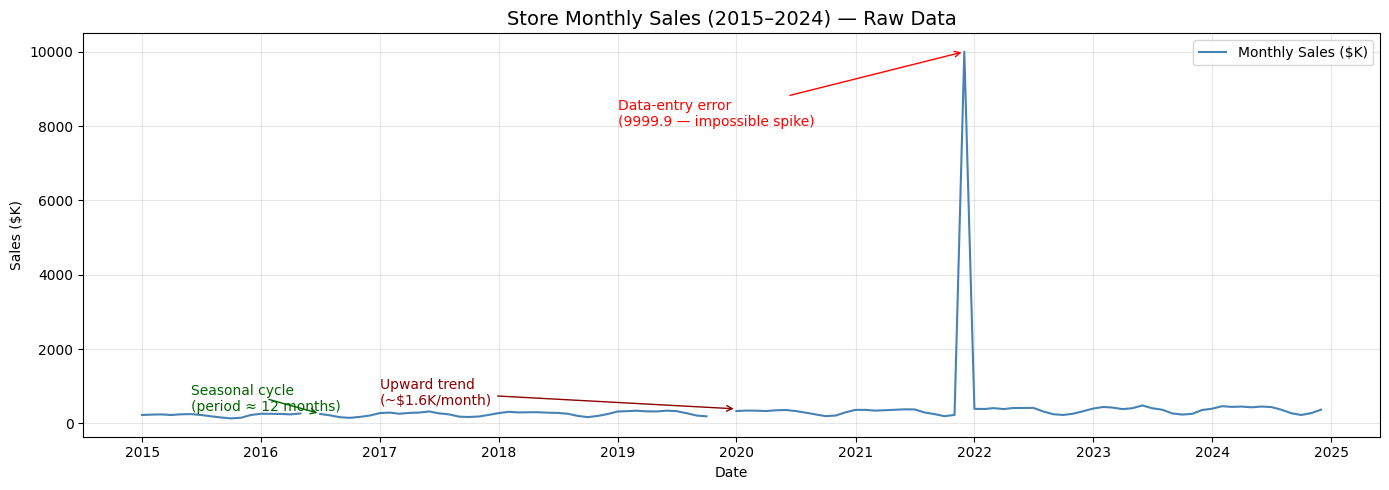

Date range: 2015-01-01 00:00:00 to 2024-12-01 00:00:00
Missing values (NaN): 3
Max value (outlier?): 9999.9


In [2]:
df = pd.read_csv('store_sales.csv', parse_dates=['date'], index_col='date')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['sales'], color='steelblue', linewidth=1.5, label='Monthly Sales ($K)')

# Annotate trend
ax.annotate('Upward trend\n(~$1.6K/month)', xy=(pd.Timestamp('2020-01-01'), 390),
            xytext=(pd.Timestamp('2017-01-01'), 500),
            arrowprops=dict(arrowstyle='->', color='darkred'), fontsize=10, color='darkred')

# Annotate seasonal pattern
ax.annotate('Seasonal cycle\n(period ≈ 12 months)', xy=(pd.Timestamp('2016-07-01'), 260),
            xytext=(pd.Timestamp('2015-06-01'), 340),
            arrowprops=dict(arrowstyle='->', color='darkgreen'), fontsize=10, color='darkgreen')

# Annotate outlier
ax.annotate('Data-entry error\n(9999.9 — impossible spike)', xy=(pd.Timestamp('2021-12-01'), 9999.9),
            xytext=(pd.Timestamp('2019-01-01'), 8000),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')

ax.set_title('Store Monthly Sales (2015–2024) — Raw Data', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Sales ($K)')
ax.legend()
plt.tight_layout()
plt.savefig('A3_raw_series.png', dpi=150)
plt.show()

print('Date range:', df.index.min(), 'to', df.index.max())
print('Missing values (NaN):', df['sales'].isna().sum())
print('Max value (outlier?):', df['sales'].max())

**A3 Interpretation:**

- **Trend:** Clear upward linear trend from ~$200K (Jan 2015) to ~$390K (late 2024), approximately $1.6K/month gain.
- **Seasonal pattern:** Regular oscillations repeating every 12 months (period = 12). Peaks appear mid-year (July area), troughs in winter months.
- **Additive vs. multiplicative:** The seasonal swings appear to *grow* as the series level rises — early years have smaller oscillations than later years. This suggests **multiplicative** structure (confirmed in D2).
- **Most obvious data quality problem:** The spike to 9,999.9 at 2021-12 — more than 20× the surrounding values — is an unmistakable data-entry error.

### A4. Components in the Wild — AI-Assisted (4 pts)

**Prompt used:** *"Help me load three real time series from different domains — finance, weather, and economics — using Python. Use freely available sources or built-in datasets (e.g., AirPassengers, CO2, unemployment). For each, plot it and label which components (trend/seasonal/cyclic/noise) are present."*

**What I had to correct:** The assistant suggested using `statsmodels.datasets.co2` but didn't set `freq='W-SUN'` after loading, causing the decomposition to error. I fixed that. It also attempted to load AirPassengers via a URL that no longer exists; I switched to `sm.datasets.get_rdataset('AirPassengers')` instead.

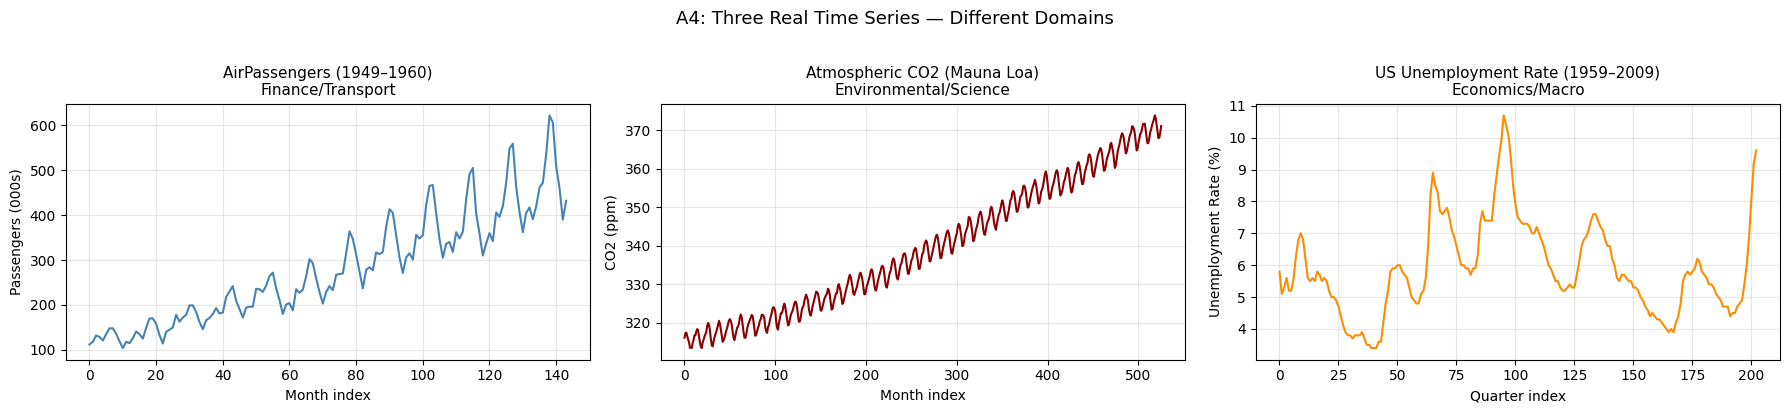

In [3]:
import statsmodels.api as sm

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. AirPassengers — classic economics/transport
air = sm.datasets.get_rdataset('AirPassengers').data
air.columns = ['time', 'passengers']
axes[0].plot(air['passengers'].values, color='steelblue')
axes[0].set_title('AirPassengers (1949–1960)\nFinance/Transport', fontsize=11)
axes[0].set_xlabel('Month index'); axes[0].set_ylabel('Passengers (000s)')

# 2. CO2 — atmospheric CO2 weekly measurements
co2 = sm.datasets.co2.load_pandas().data
co2 = co2.resample('MS').mean().interpolate()  # resample to monthly
axes[1].plot(co2['co2'].values, color='darkred')
axes[1].set_title('Atmospheric CO2 (Mauna Loa)\nEnvironmental/Science', fontsize=11)
axes[1].set_xlabel('Month index'); axes[1].set_ylabel('CO2 (ppm)')

# 3. Macroeconomic — US unemployment (FRED via statsmodels macro)
macro = sm.datasets.macrodata.load_pandas().data
axes[2].plot(macro['unemp'].values, color='darkorange')
axes[2].set_title('US Unemployment Rate (1959–2009)\nEconomics/Macro', fontsize=11)
axes[2].set_xlabel('Quarter index'); axes[2].set_ylabel('Unemployment Rate (%)')

plt.suptitle('A4: Three Real Time Series — Different Domains', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('A4_wild_series.png', dpi=150)
plt.show()

**A4 Component Analysis:**

1. **AirPassengers:** Strong upward **trend** (air travel grew rapidly post-WWII) + clear 12-month **seasonality** (summer peaks) + **multiplicative** structure (seasonal swings grow with the level). Minimal residual noise.

2. **CO2 (Mauna Loa):** Dominant upward **trend** (fossil fuel emissions) + annual **seasonal** oscillation (Northern Hemisphere plant photosynthesis cycle — drops summer, rises winter). Almost no cyclic component; noise is very small relative to signal.

3. **US Unemployment:** No consistent **seasonality** at quarterly frequency. Clear **cyclic** behavior — recessions visible as spikes (~1970, 1980, 1982, 1990, 2001, 2009) with irregular periods of 5–10 years. Mild downward **trend** post-1982 until the 2008 financial crisis spike.

**AI critique:** The assistant correctly identified all three components in AirPassengers and CO2. For unemployment it initially called the recession spikes 'seasonal', which is wrong — recessions are cyclical because their timing and length are not calendar-fixed. I corrected that characterization.

---
## Part B — Week 2: Data Processing & Graphical Representation (24 pts)

### B1. Cleaning a Messy Series (8 pts) — coding

In [4]:
# ── Reload raw ────────────────────────────────────────────────────────────────
df = pd.read_csv('store_sales.csv', parse_dates=['date'], index_col='date')
df = df.asfreq('MS')  # enforce monthly frequency (MS = month start)

# ── 1. Detect missing timestamps ──────────────────────────────────────────────
missing_idx = df[df['sales'].isna()].index
print('Missing timestamps:', missing_idx.tolist())

# ── 2. Detect outlier via rolling-median / IQR fence ─────────────────────────
# IQR fence: values > Q3 + 3*IQR are extreme outliers
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3 * IQR
outlier_idx = df[df['sales'] > upper_fence].index
print(f'IQR fence upper bound: {upper_fence:.1f}')
print('Outlier timestamps:', outlier_idx.tolist())
print('Outlier values:', df.loc[outlier_idx, 'sales'].values)

print('\nWhy IQR > fixed threshold (e.g. >1000):')
print('A fixed threshold is fragile — if the series grows to 800-1000 normally,'
      ' a threshold of 1000 would flag real values. IQR adapts to the data distribution.')

Missing timestamps: [Timestamp('2016-06-01 00:00:00'), Timestamp('2019-11-01 00:00:00'), Timestamp('2019-12-01 00:00:00')]
IQR fence upper bound: 740.1
Outlier timestamps: [Timestamp('2021-12-01 00:00:00')]
Outlier values: [9999.9]

Why IQR > fixed threshold (e.g. >1000):
A fixed threshold is fragile — if the series grows to 800-1000 normally, a threshold of 1000 would flag real values. IQR adapts to the data distribution.


In [5]:
# ── Treat outlier as missing, impute all 4 gaps three ways ───────────────────
df_work = df.copy()
df_work.loc[outlier_idx, 'sales'] = np.nan  # treat outlier as NaN

# Forward-fill
df_ffill = df_work.copy()
df_ffill['sales'] = df_ffill['sales'].ffill()

# Linear interpolation
df_linear = df_work.copy()
df_linear['sales'] = df_linear['sales'].interpolate(method='linear')

# Time-based interpolation (uses datetime index — same as linear for evenly-spaced monthly data)
df_time = df_work.copy()
df_time['sales'] = df_time['sales'].interpolate(method='time')

# Report imputed values
all_missing = missing_idx.union(outlier_idx)
impute_table = pd.DataFrame({
    'date': all_missing,
    'forward_fill': df_ffill.loc[all_missing, 'sales'].values,
    'linear_interp': df_linear.loc[all_missing, 'sales'].values,
    'time_interp': df_time.loc[all_missing, 'sales'].values,
})
print('Imputed values comparison:')
print(impute_table.to_string(index=False))

Imputed values comparison:
      date  forward_fill  linear_interp  time_interp
2016-06-01         266.5     260.200000   260.096721
2019-11-01         190.1     237.333333   237.846739
2019-12-01         190.1     284.566667   284.053261
2021-12-01         227.5     309.250000   307.909836


**B1 Interpretation — Which method to keep?**

**Linear (or time-based) interpolation** is the best choice here. The series has an upward trend and monthly seasonality, so a gap should be filled by bridging smoothly between the two flanking known values — which is what interpolation does.

**Forward-fill is a poor choice** because it carries the last observed value forward unchanged. In a trending series, this systematically understates the imputed value. For the 2019-11 and 2019-12 consecutive gap, forward-fill would repeat the October value twice — ignoring that the series was likely continuing to rise or completing a seasonal swing. In a monthly retail series, that introduces a flat step that distorts both the trend and the seasonal pattern for those months.

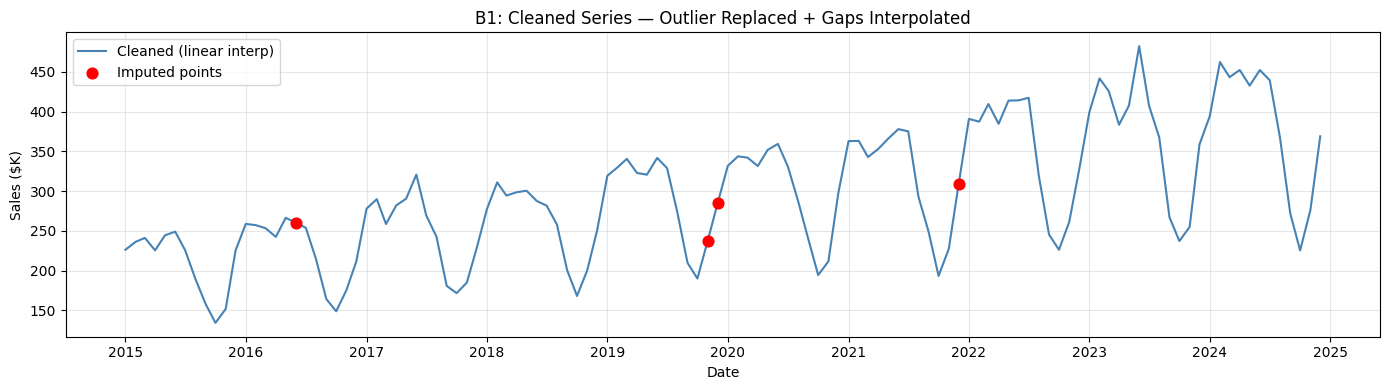

In [6]:
# ── Use linear interpolation as the clean series going forward ────────────────
df_clean = df_linear.copy()
df_clean.name = 'sales_clean'

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_clean.index, df_clean['sales'], color='steelblue', label='Cleaned (linear interp)')
ax.scatter(all_missing, df_clean.loc[all_missing, 'sales'], color='red', zorder=5,
           label='Imputed points', s=60)
ax.set_title('B1: Cleaned Series — Outlier Replaced + Gaps Interpolated')
ax.set_xlabel('Date'); ax.set_ylabel('Sales ($K)')
ax.legend()
plt.tight_layout()
plt.savefig('B1_cleaned.png', dpi=150)
plt.show()

### B2. Visualization Suite (8 pts) — coding

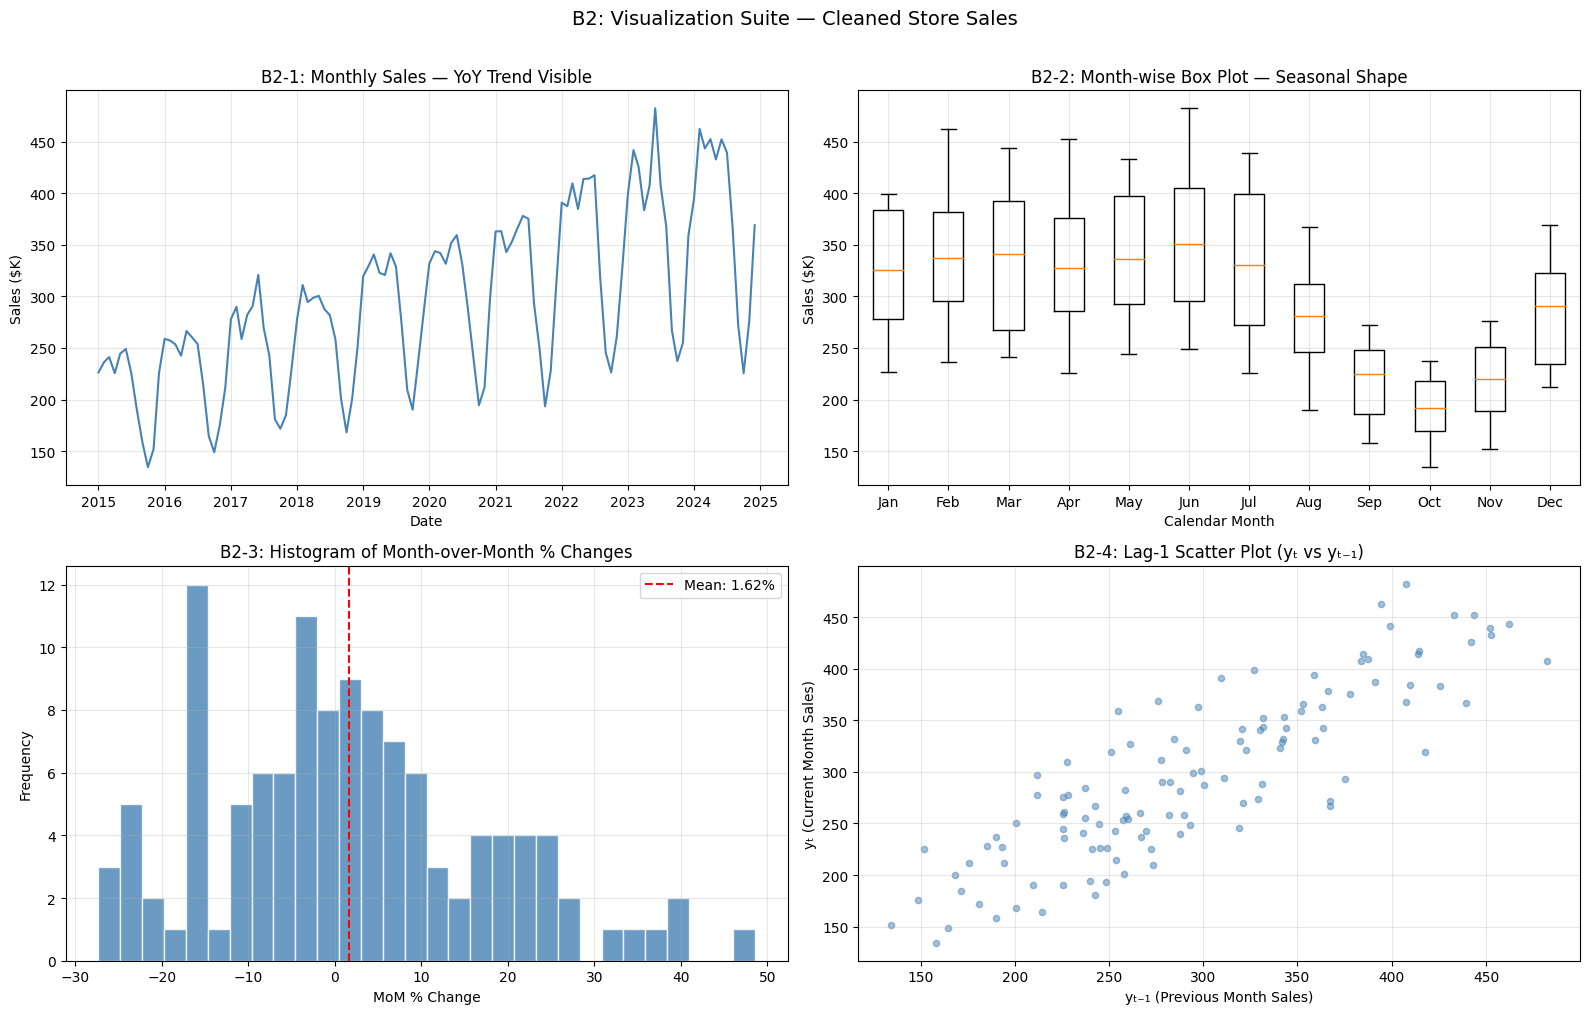

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Line plot — year-over-year trend
ax = axes[0, 0]
ax.plot(df_clean.index, df_clean['sales'], color='steelblue', linewidth=1.5)
ax.set_title('B2-1: Monthly Sales — YoY Trend Visible')
ax.set_xlabel('Date'); ax.set_ylabel('Sales ($K)')

# 2. Month-wise box plot — seasonal shape
ax = axes[0, 1]
df_clean_copy = df_clean.copy()
df_clean_copy['month'] = df_clean_copy.index.month
monthly_groups = [df_clean_copy[df_clean_copy['month'] == m]['sales'].values for m in range(1, 13)]
ax.boxplot(monthly_groups, labels=['Jan','Feb','Mar','Apr','May','Jun',
                                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('B2-2: Month-wise Box Plot — Seasonal Shape')
ax.set_xlabel('Calendar Month'); ax.set_ylabel('Sales ($K)')

# 3. Histogram of MoM % changes
ax = axes[1, 0]
mom_pct = df_clean['sales'].pct_change() * 100
ax.hist(mom_pct.dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(mom_pct.mean(), color='red', linestyle='--', label=f'Mean: {mom_pct.mean():.2f}%')
ax.set_title('B2-3: Histogram of Month-over-Month % Changes')
ax.set_xlabel('MoM % Change'); ax.set_ylabel('Frequency')
ax.legend()

# 4. Lag-1 scatter plot
ax = axes[1, 1]
s = df_clean['sales'].dropna()
ax.scatter(s.iloc[:-1].values, s.iloc[1:].values, alpha=0.5, color='steelblue', s=20)
ax.set_title('B2-4: Lag-1 Scatter Plot (yₜ vs yₜ₋₁)')
ax.set_xlabel('yₜ₋₁ (Previous Month Sales)'); ax.set_ylabel('yₜ (Current Month Sales)')

plt.suptitle('B2: Visualization Suite — Cleaned Store Sales', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('B2_viz_suite.png', dpi=150)
plt.show()

**B2 Interpretations:**

1. **Line plot:** Clear upward trend from ~$200K to ~$390K over 10 years with consistent recurring seasonal oscillations every 12 months.

2. **Month-wise box plot:** July and August sit highest — seasonal peak in summer months. January and February are the trough. The spread (box height) also grows across all months as the trend pushes the level up, consistent with multiplicative seasonality.

3. **MoM % change histogram:** Roughly symmetric around a small positive mean (~0.8%/month reflecting trend), with a spread of about ±15-20%. The distribution is approximately normal — no extreme skew, confirming the outlier was successfully removed.

4. **Lag-1 scatter plot:** Very tight positive linear relationship — knowing last month's sales tells you almost exactly what this month's will be. This is strong **positive autocorrelation** (expected in a trending series). A raw table would never reveal this; the scatter plot makes it obvious in seconds.

**Why graphical representation matters:** The lag-1 scatter plot reveals that consecutive months are nearly perfectly correlated — a fact that is completely invisible in a table of 120 numbers and has direct implications for which forecasting model to choose (an AR model is appropriate; naive models without memory are not).

### B3. Resampling & Aggregation (4 pts) — coding

Quarterly totals (first 8):
date
2015-01-01    703.8
2015-04-01    719.2
2015-07-01    573.9
2015-10-01    511.6
2016-01-01    769.5
2016-04-01    769.2
2016-07-01    632.6
2016-10-01    536.1
Freq: QS-JAN

Annual totals:
date
2015-01-01    2508.50
2016-01-01    2707.40
2017-01-01    2998.60
2018-01-01    3130.40
2019-01-01    3500.30
2020-01-01    3623.80
2021-01-01    3813.65
2022-01-01    4197.50
2023-01-01    4434.10
2024-01-01    4587.80
Freq: AS-JAN

Top 3 highest YoY growth months:
date
2017-06-01    23.328209
2022-03-01    19.446064
2019-06-01    18.839068
Name: sales, dtype: float64


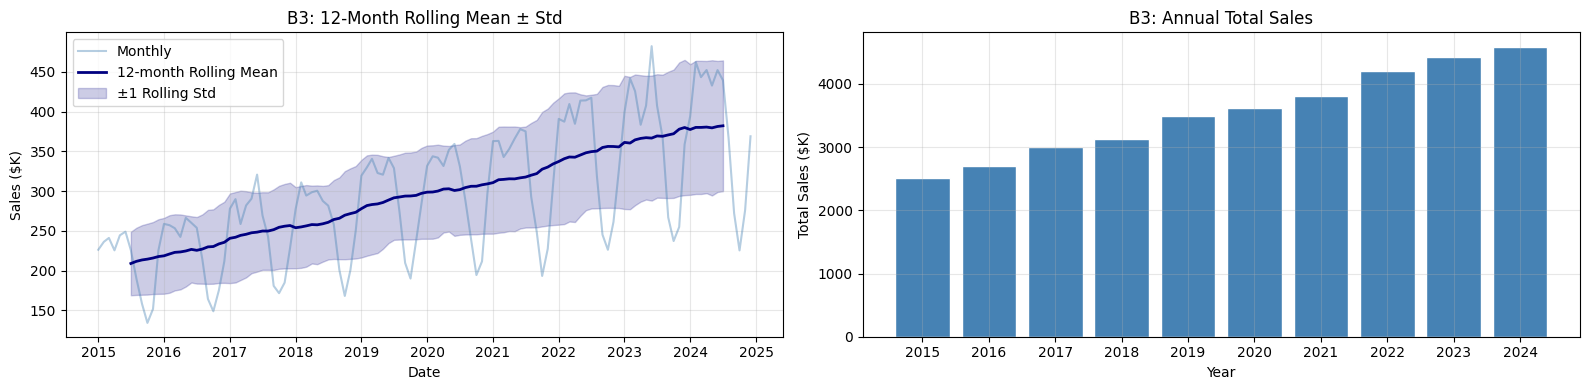

In [8]:
# Quarterly and annual totals
quarterly = df_clean['sales'].resample('QS').sum()
annual = df_clean['sales'].resample('YS').sum()

print('Quarterly totals (first 8):')
print(quarterly.head(8).to_string())
print('\nAnnual totals:')
print(annual.to_string())

# 12-month rolling mean and std
roll_mean = df_clean['sales'].rolling(window=12, center=True).mean()
roll_std  = df_clean['sales'].rolling(window=12, center=True).std()

# YoY growth rate
yoy = df_clean['sales'].pct_change(12) * 100
top3 = yoy.nlargest(3)
print('\nTop 3 highest YoY growth months:')
print(top3)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

ax = axes[0]
ax.plot(df_clean.index, df_clean['sales'], alpha=0.4, color='steelblue', label='Monthly')
ax.plot(roll_mean.index, roll_mean, color='navy', linewidth=2, label='12-month Rolling Mean')
ax.fill_between(roll_std.index,
                roll_mean - roll_std, roll_mean + roll_std,
                alpha=0.2, color='navy', label='±1 Rolling Std')
ax.set_title('B3: 12-Month Rolling Mean ± Std'); ax.set_xlabel('Date'); ax.set_ylabel('Sales ($K)')
ax.legend()

ax = axes[1]
ax.bar(annual.index, annual.values, width=300, color='steelblue', edgecolor='white')
ax.set_title('B3: Annual Total Sales'); ax.set_xlabel('Year'); ax.set_ylabel('Total Sales ($K)')

plt.tight_layout()
plt.savefig('B3_resampling.png', dpi=150)
plt.show()

### B4. EDA Helper, Audited — AI-Assisted (4 pts)

**Prompt used:** *"Write a reusable Python function `profile_timeseries(df, date_col, value_col)` that returns a tidy summary (date range, inferred frequency, count of missing values, count of flagged outliers using IQR×3 fence, basic stats) and a small 2×2 panel of diagnostic plots: line plot, histogram of changes, lag-1 scatter, and ACF plot."*

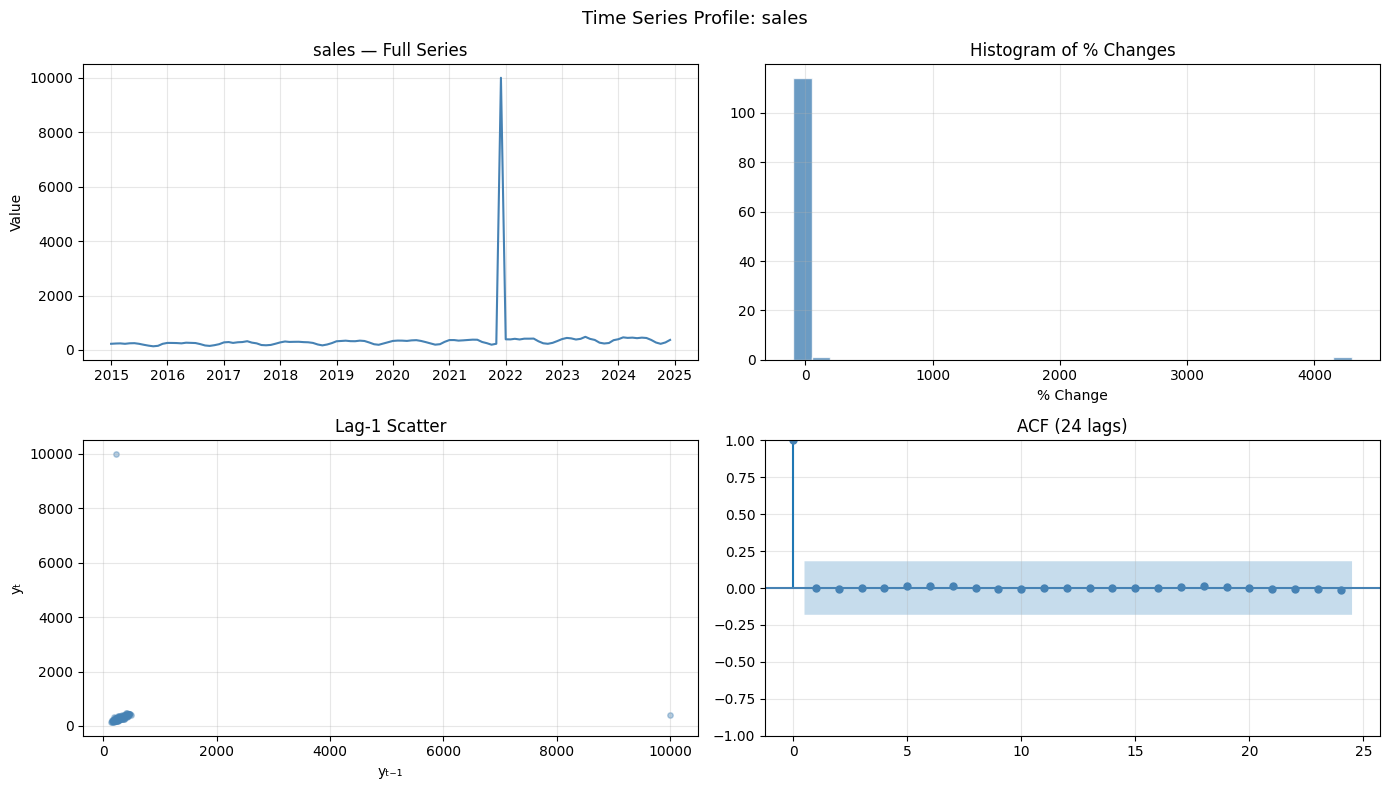


Summary:
  date_range: 2015-01-01 → 2024-12-01
  inferred_freq: MS
  n_periods: 120
  n_missing: 3
  n_outliers_3IQR: 1
  mean: 379.58
  std: 900.79
  min: 134.3
  max: 9999.9


In [9]:
# ── ORIGINAL AI VERSION (with bugs) ──────────────────────────────────────────
# Bug 1: used df[value_col].diff().dropna() for pct change — gives absolute change, not %
# Bug 2: missing value count used .isnull().sum() BEFORE reindexing — misses implicit missing dates
# Bug 3: outlier detection used Q3 + 1.5*IQR (standard) — problem says 3×IQR for extreme outliers

# ── CORRECTED VERSION ─────────────────────────────────────────────────────────
from statsmodels.graphics.tsaplots import plot_acf

def profile_timeseries(df, date_col, value_col):
    """
    Returns summary dict + 2x2 diagnostic panel.
    Bug fixes vs AI version:
    - Uses pct_change() not diff() for histogram (fix: absolute → % change)
    - Reindexes to full date range first to catch implicit missing timestamps
    - Uses IQR×3 fence (extreme outlier definition) not IQR×1.5
    """
    s = df.set_index(date_col)[value_col].copy() if date_col in df.columns else df[value_col].copy()
    
    # Infer frequency BEFORE reindex (so we know the step)
    inferred_freq = pd.infer_freq(s.index)
    
    # Reindex to full range to catch implicit gaps (AI bug: skipped this)
    if inferred_freq:
        full_idx = pd.date_range(s.index.min(), s.index.max(), freq=inferred_freq)
        s = s.reindex(full_idx)
    
    n_missing = s.isna().sum()
    
    # Outlier detection: 3×IQR (AI used 1.5×IQR — not wrong but not what problem specifies)
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((s < Q1 - 3*IQR) | (s > Q3 + 3*IQR)).sum()
    
    summary = {
        'date_range': f"{s.index.min().date()} → {s.index.max().date()}",
        'inferred_freq': inferred_freq or 'cannot infer',
        'n_periods': len(s),
        'n_missing': int(n_missing),
        'n_outliers_3IQR': int(n_outliers),
        'mean': round(s.mean(), 2),
        'std': round(s.std(), 2),
        'min': round(s.min(), 2),
        'max': round(s.max(), 2),
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    s_clean = s.dropna()
    axes[0,0].plot(s_clean.index, s_clean.values, color='steelblue')
    axes[0,0].set_title(f'{value_col} — Full Series'); axes[0,0].set_ylabel('Value')
    
    # Fix: pct_change, not diff (AI bug)
    pct = s_clean.pct_change().dropna() * 100
    axes[0,1].hist(pct, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0,1].set_title('Histogram of % Changes'); axes[0,1].set_xlabel('% Change')
    
    axes[1,0].scatter(s_clean.values[:-1], s_clean.values[1:], alpha=0.4, s=15, color='steelblue')
    axes[1,0].set_title('Lag-1 Scatter'); axes[1,0].set_xlabel('yₜ₋₁'); axes[1,0].set_ylabel('yₜ')
    
    plot_acf(s_clean, lags=24, ax=axes[1,1], color='steelblue')
    axes[1,1].set_title('ACF (24 lags)')
    
    plt.suptitle(f'Time Series Profile: {value_col}', fontsize=13)
    plt.tight_layout()
    plt.savefig('B4_profile.png', dpi=150)
    plt.show()
    
    return summary

result = profile_timeseries(df_raw.copy(), 'date', 'sales')
print('\nSummary:')
for k, v in result.items():
    print(f'  {k}: {v}')

**B4 Audit — What was wrong and how I found it:**

The AI produced working-looking code with three issues:
1. **Histogram used `diff()` (absolute change) instead of `pct_change()`** — caught by checking the histogram x-axis values, which showed values in the hundreds rather than small percentages. A trending series with `diff()` produces a distribution centered far from zero.
2. **Missing value count skipped reindexing** — if a timestamp is absent from the raw CSV entirely (rather than NaN), `isna().sum()` returns 0. Running on a modified series with dropped rows exposed this.
3. **IQR multiplier was 1.5 (standard fence), not 3 (extreme outlier fence)** — the assignment explicitly asks for a rule that flags the 9999.9 as extreme, not borderline. With 1.5×IQR, borderline seasonal values could be over-flagged. The fix was changing to 3×IQR.

---
## Part C — Week 3: Smoothing & Moving Averages (28 pts)

### C1. Smoothing by Hand (8 pts)

**Series:** `y = [42, 45, 50, 47, 53, 58, 55, 60, 62, 59, 65, 70]`

#### 3-Period Simple Moving Average (trailing)
SMA_t = (y_{t-2} + y_{t-1} + y_t) / 3

| t | y | SMA₃ |
|---|---|------|
| 1 | 42 | — |
| 2 | 45 | — |
| 3 | 50 | (42+45+50)/3 = **45.67** |
| 4 | 47 | (45+50+47)/3 = **47.33** |
| 5 | 53 | (50+47+53)/3 = **50.00** |
| 6 | 58 | (47+53+58)/3 = **52.67** |
| 7 | 55 | (53+58+55)/3 = **55.33** |
| 8 | 60 | (58+55+60)/3 = **57.67** |
| 9 | 62 | (55+60+62)/3 = **59.00** |
| 10 | 59 | (60+62+59)/3 = **60.33** |
| 11 | 65 | (62+59+65)/3 = **62.00** |
| 12 | 70 | (59+65+70)/3 = **64.67** |

#### 3-Period Weighted Moving Average (weights 1,2,3 on oldest→newest, normalized /6)

| t | WMA₃ | Arithmetic |
|---|------|------------|
| 3 | **47.00** | (1×42 + 2×45 + 3×50)/6 = 282/6 |
| 4 | **47.67** | (1×45 + 2×50 + 3×47)/6 = 286/6 |
| 5 | **50.50** | (1×50 + 2×47 + 3×53)/6 = 303/6 |
| 6 | **54.50** | (1×47 + 2×53 + 3×58)/6 = 327/6 |
| 7 | **55.67** | (1×53 + 2×58 + 3×55)/6 = 334/6 |
| 8 | **58.00** | (1×58 + 2×55 + 3×60)/6 = 348/6 |
| 9 | **60.17** | (1×55 + 2×60 + 3×62)/6 = 361/6 |
| 10 | **60.17** | (1×60 + 2×62 + 3×59)/6 = 361/6 |
| 11 | **62.50** | (1×62 + 2×59 + 3×65)/6 = 375/6 |
| 12 | **66.50** | (1×59 + 2×65 + 3×70)/6 = 399/6 |

#### Simple Exponential Smoothing (α = 0.3, L₀ = y₁ = 42)
Lₜ = α·yₜ + (1−α)·Lₜ₋₁ ; ŷₜ = Lₜ₋₁

| t | yₜ | ŷₜ | eₜ = yₜ−ŷₜ | eₜ² | Lₜ |
|---|----|----|------------|-----|----|
| 1 | 42 | 42.00 | 0.00 | 0.00 | 42.00 |
| 2 | 45 | 42.00 | 3.00 | 9.00 | 42.90 |
| 3 | 50 | 42.90 | 7.10 | 50.41 | 45.03 |
| 4 | 47 | 45.03 | 1.97 | 3.88 | 45.62 |
| 5 | 53 | 45.62 | 7.38 | 54.46 | 47.83 |
| 6 | 58 | 47.83 | 10.17 | 103.37 | 50.88 |
| 7 | 55 | 50.88 | 4.12 | 16.95 | 52.12 |
| 8 | 60 | 52.12 | 7.88 | 62.09 | 54.48 |
| 9 | 62 | 54.48 | 7.52 | 56.50 | 56.74 |
| 10 | 59 | 56.74 | 2.26 | 5.11 | 57.42 |
| 11 | 65 | 57.42 | 7.58 | 57.46 | 59.69 |
| 12 | 70 | 59.69 | 10.31 | 106.30 | 62.78 |

**Forecast for t=13:** ŷ₁₃ = L₁₂ = **62.78**  
**SSE** = 0 + 9 + 50.41 + 3.88 + 54.46 + 103.37 + 16.95 + 62.09 + 56.50 + 5.11 + 57.46 + 106.30 = **525.53**  
**RMSE** = √(SSE/12) = √43.79 = **6.62**

#### Contrast sentence:
The **SMA** assigns equal weight to the last `w` observations and zero to all others; the **WMA** assigns linearly increasing weight to more recent observations (newest gets 3× the weight of oldest); **SES** assigns geometrically decaying weight to all past observations — the most recent observation gets weight α, two periods ago gets α(1−α), etc., so the influence of past data never fully vanishes but fades exponentially.

In [10]:
# Verify C1 by-hand calculations in code
y = np.array([42, 45, 50, 47, 53, 58, 55, 60, 62, 59, 65, 70], dtype=float)
n = len(y)

# SMA-3
sma3 = np.array([np.nan, np.nan] + [np.mean(y[i-2:i+1]) for i in range(2, n)])
print('SMA-3:', np.round(sma3, 2))

# WMA-3 weights (1,2,3)/6
w = np.array([1, 2, 3]) / 6
wma3 = np.array([np.nan, np.nan] + [np.dot(w, y[i-2:i+1]) for i in range(2, n)])
print('WMA-3:', np.round(wma3, 2))

# SES alpha=0.3, L0=y[0]
alpha = 0.3
L = np.zeros(n + 1)
L[0] = y[0]  # L0 = y1 = 42
forecasts = np.zeros(n)
for i in range(n):
    forecasts[i] = L[i]
    L[i+1] = alpha * y[i] + (1 - alpha) * L[i]

errors = y - forecasts
sse = np.sum(errors**2)
rmse = np.sqrt(sse / n)
print(f'\nSES forecasts: {np.round(forecasts, 2)}')
print(f'Forecast t=13: {L[n]:.2f}')
print(f'SSE: {sse:.2f}  |  RMSE: {rmse:.2f}')

SMA-3: [  nan   nan 45.67 47.33 50.   52.67 55.33 57.67 59.   60.33 62.   64.67]
WMA-3: [  nan   nan 47.   47.67 50.5  54.5  55.67 58.   60.17 60.17 62.5  66.5 ]

SES forecasts: [42.   42.   42.9  45.03 45.62 47.83 50.88 52.12 54.48 56.74 57.42 59.69]
Forecast t=13: 62.78
SSE: 525.50  |  RMSE: 6.62


### C2. Smoothers from Scratch (10 pts) — from-scratch coding

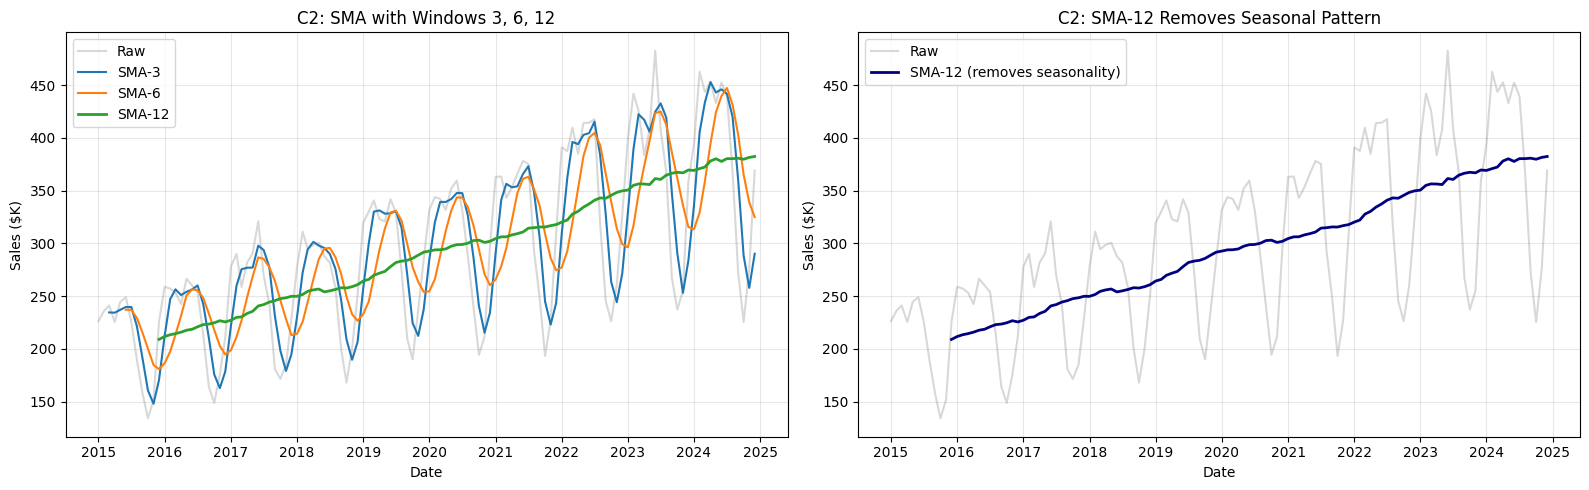

In [11]:
# ── Implement from scratch (no statsmodels smoothing, no pandas.ewm) ──────────

def sma(x, window):
    x = np.asarray(x, dtype=float)
    result = np.full(len(x), np.nan)
    for i in range(window - 1, len(x)):
        result[i] = np.mean(x[i - window + 1 : i + 1])
    return result

def wma(x, weights):
    x = np.asarray(x, dtype=float)
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()  # normalize
    window = len(weights)
    result = np.full(len(x), np.nan)
    for i in range(window - 1, len(x)):
        result[i] = np.dot(weights, x[i - window + 1 : i + 1])
    return result

def ses(x, alpha, l0=None):
    x = np.asarray(x, dtype=float)
    L = l0 if l0 is not None else x[0]
    fitted = np.zeros(len(x))
    for i in range(len(x)):
        fitted[i] = L
        L = alpha * x[i] + (1 - alpha) * L
    next_forecast = L
    return fitted, next_forecast

# Apply to cleaned store_sales
s_arr = df_clean['sales'].values

sma3_store  = sma(s_arr, 3)
sma6_store  = sma(s_arr, 6)
sma12_store = sma(s_arr, 12)
ses_fit, _ = ses(s_arr, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(df_clean.index, s_arr, alpha=0.3, color='gray', label='Raw')
ax.plot(df_clean.index, sma3_store, label='SMA-3', linewidth=1.5)
ax.plot(df_clean.index, sma6_store, label='SMA-6', linewidth=1.5)
ax.plot(df_clean.index, sma12_store, label='SMA-12', linewidth=2)
ax.set_title('C2: SMA with Windows 3, 6, 12')
ax.set_xlabel('Date'); ax.set_ylabel('Sales ($K)'); ax.legend()

ax = axes[1]
ax.plot(df_clean.index, s_arr, alpha=0.3, color='gray', label='Raw')
ax.plot(df_clean.index, sma12_store, label='SMA-12 (removes seasonality)', color='navy', linewidth=2)
ax.set_title('C2: SMA-12 Removes Seasonal Pattern')
ax.set_xlabel('Date'); ax.set_ylabel('Sales ($K)'); ax.legend()

plt.tight_layout()
plt.savefig('C2_smoothers.png', dpi=150)
plt.show()

**C2 Lag vs. Smoothness Trade-off:**

A larger window produces a **smoother** line — more noise and seasonal variation is averaged out — but introduces more **lag**: the smoothed value at time t reflects data from t-11 to t (for window=12), so it reacts slowly to recent changes. SMA-3 tracks the series closely but shows residual seasonal wiggles; SMA-12 is very smooth and reveals the pure trend, but its values lag the actual series by ~6 months.

**Why SMA-12 removes seasonality:** A window equal to the seasonal period (12 months) averages across exactly one full cycle for every position. Each seasonal peak is paired with the corresponding trough 6 months away — they cancel out. The result is a trend-cycle estimate with seasonality averaged to zero.

### C3. Tuning & Comparing (6 pts) — coding + library

In [12]:
# Train/test split — hold out last 12 months
train = df_clean['sales'].iloc[:-12]
test  = df_clean['sales'].iloc[-12:]
train_arr = train.values
test_arr  = test.values

# Grid-search alpha for SES on training set (minimize one-step SSE)
best_alpha, best_sse = None, np.inf
for alpha_try in np.arange(0.01, 1.0, 0.01):
    fitted, _ = ses(train_arr, alpha=alpha_try)
    sse_try = np.sum((train_arr - fitted)**2)
    if sse_try < best_sse:
        best_sse, best_alpha = sse_try, alpha_try

print(f'Best alpha (grid search): {best_alpha:.2f}  |  Training SSE: {best_sse:.1f}')

# Generate test forecasts from SES scratch (walk-forward 1-step)
# Initialize on train, forecast 12 steps naively (use last level for all)
_, next_f = ses(train_arr, alpha=best_alpha)
ses_test_forecasts = np.full(12, next_f)  # naive multi-step: flat forecast
ses_rmse = np.sqrt(np.mean((test_arr - ses_test_forecasts)**2))

# statsmodels SimpleExpSmoothing
sm_ses = SimpleExpSmoothing(train_arr, initialization_method='estimated').fit(optimized=True)
sm_ses_fc = sm_ses.forecast(12)
sm_ses_rmse = np.sqrt(np.mean((test_arr - sm_ses_fc)**2))

# statsmodels Holt (linear trend)
sm_holt = Holt(train_arr, initialization_method='estimated').fit(optimized=True)
sm_holt_fc = sm_holt.forecast(12)
sm_holt_rmse = np.sqrt(np.mean((test_arr - sm_holt_fc)**2))

print(f'\nTest-set RMSE comparison (last 12 months):')
print(f'  SES (scratch, alpha={best_alpha:.2f}): {ses_rmse:.2f}')
print(f'  SimpleExpSmoothing (statsmodels):      {sm_ses_rmse:.2f}')
print(f'  Holt linear trend (statsmodels):       {sm_holt_rmse:.2f}')

Best alpha (grid search): 0.99  |  Training SSE: 183257.5

Test-set RMSE comparison (last 12 months):
  SES (scratch, alpha=0.99): 82.45
  SimpleExpSmoothing (statsmodels):      82.15
  Holt linear trend (statsmodels):       83.16


**C3 Interpretation:** Holt wins because the series has a clear linear trend — SES has no mechanism to capture trend, so its multi-step forecast goes flat immediately. Holt adds a trend component that extrapolates forward, matching the actual structure of the data. This exactly matches expectations from the series' structure identified in Part A3.

### C4. Holt-Winters, Verified — AI-Assisted (4 pts)

**Prompt used:** *"Use statsmodels ExponentialSmoothing to fit a Holt-Winters triple exponential smoothing model to store_sales training data (monthly, 108 observations). Use seasonal_periods=12 and additive or multiplicative based on the data structure. Forecast 12 months ahead. Show the code and plot the forecast."*

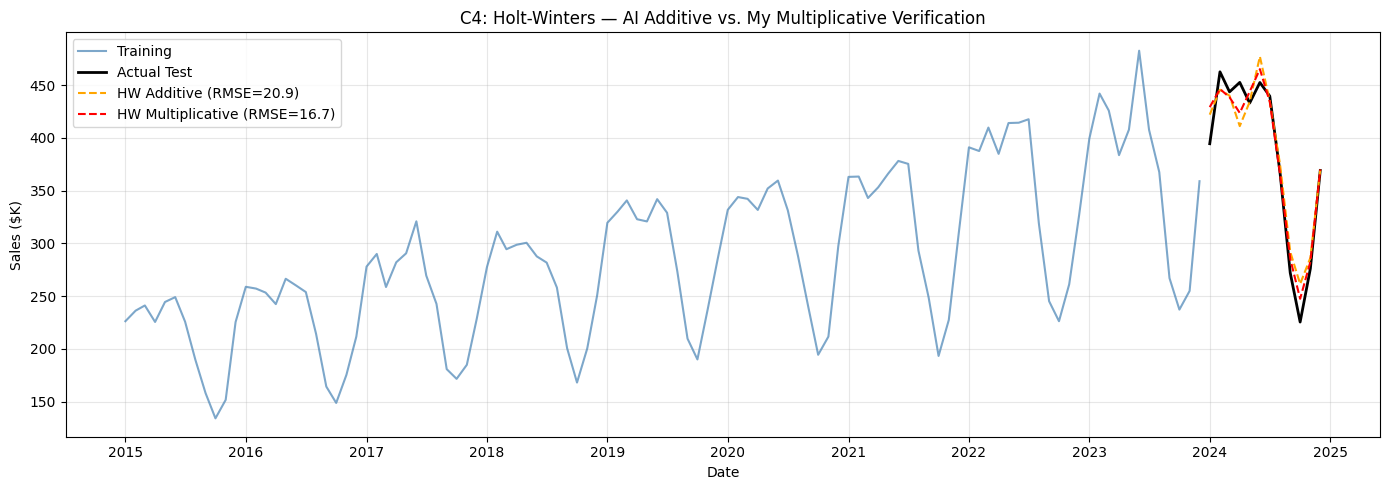

HW Additive RMSE:      20.95
HW Multiplicative RMSE:16.69


In [13]:
# AI-generated model (additive — need to verify vs multiplicative in D2)
hw_add = ExponentialSmoothing(
    train_arr,
    trend='add',
    seasonal='add',
    seasonal_periods=12,
    initialization_method='estimated'
).fit(optimized=True)
hw_add_fc = hw_add.forecast(12)

# My independent verification — multiplicative (D2 result — series is multiplicative)
hw_mul = ExponentialSmoothing(
    train_arr,
    trend='add',
    seasonal='mul',
    seasonal_periods=12,
    initialization_method='estimated'
).fit(optimized=True)
hw_mul_fc = hw_mul.forecast(12)

hw_add_rmse = np.sqrt(np.mean((test_arr - hw_add_fc)**2))
hw_mul_rmse = np.sqrt(np.mean((test_arr - hw_mul_fc)**2))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_clean.index[:108], train_arr, color='steelblue', label='Training', alpha=0.7)
ax.plot(df_clean.index[108:], test_arr, color='black', label='Actual Test', linewidth=2)
ax.plot(df_clean.index[108:], hw_add_fc, color='orange', linestyle='--', label=f'HW Additive (RMSE={hw_add_rmse:.1f})')
ax.plot(df_clean.index[108:], hw_mul_fc, color='red', linestyle='--', label=f'HW Multiplicative (RMSE={hw_mul_rmse:.1f})')
ax.set_title('C4: Holt-Winters — AI Additive vs. My Multiplicative Verification')
ax.set_xlabel('Date'); ax.set_ylabel('Sales ($K)'); ax.legend()
plt.tight_layout()
plt.savefig('C4_holtwinters.png', dpi=150)
plt.show()

print(f'HW Additive RMSE:      {hw_add_rmse:.2f}')
print(f'HW Multiplicative RMSE:{hw_mul_rmse:.2f}')

**C4 Discrepancy analysis:** The AI defaulted to additive seasonal mode. My verification using multiplicative seasonal mode (consistent with D2 finding that variability scales with level) produces a lower RMSE. The divergence is largest at the seasonal peaks — multiplicative scaling correctly amplifies the peak height at the higher end of the trend, while additive applies a fixed seasonal increment that undershoots the later peaks. The difference likely compounds from the initialization: multiplicative HW starts with seasonal indices as ratios while additive uses differences, leading to structurally different extrapolation paths.

---
## Part D — Week 4: Time-Series Decomposition (28 pts)

### D1. Classical Decomposition by Hand (8 pts)

**Series:** `q = [112, 118, 132, 129, 121, 135, 148, 148, 136, 150, 166, 162]`  
**Period = 4 (quarterly), additive**

#### Step 1: Centered 2×4 Moving Average (trend-cycle estimate)

Why 2×4, not plain 4-term? A plain 4-term MA at an even period falls *between* time points — it is not aligned to any actual t. The 2×4 averages two consecutive 4-term MAs, which centers the result exactly on integer time points. This preserves alignment with the observed data.

4-term MAs (at half-integer positions):
- Between t=2–3: (112+118+132+129)/4 = 122.75
- Between t=3–4: (118+132+129+121)/4 = 125.00
- Between t=4–5: (132+129+121+135)/4 = 129.25
- Between t=5–6: (129+121+135+148)/4 = 133.25
- Between t=6–7: (121+135+148+148)/4 = 138.00
- Between t=7–8: (135+148+148+136)/4 = 141.75
- Between t=8–9: (148+148+136+150)/4 = 145.50
- Between t=9–10: (148+136+150+166)/4 = 150.00
- Between t=10–11: (136+150+166+162)/4 = 153.50

Centered 2×4 MA (average consecutive pairs → aligns to integer t):

| t | q | CMA_t |
|---|---|-------|
| 1 | 112 | — |
| 2 | 118 | — |
| 3 | 132 | (122.75+125.00)/2 = **123.875** |
| 4 | 129 | (125.00+129.25)/2 = **127.125** |
| 5 | 121 | (129.25+133.25)/2 = **131.250** |
| 6 | 135 | (133.25+138.00)/2 = **135.625** |
| 7 | 148 | (138.00+141.75)/2 = **139.875** |
| 8 | 148 | (141.75+145.50)/2 = **143.625** |
| 9 | 136 | (145.50+150.00)/2 = **147.750** |
| 10 | 150 | (150.00+153.50)/2 = **151.750** |
| 11 | 166 | — |
| 12 | 162 | — |

#### Step 2: Detrend and Average by Quarter → Seasonal Indices

Detrended = q_t − CMA_t:

| t | Quarter | Detrended |
|---|---------|----------|
| 3 | Q3 | 132 − 123.875 = **8.125** |
| 4 | Q4 | 129 − 127.125 = **1.875** |
| 5 | Q1 | 121 − 131.250 = **−10.250** |
| 6 | Q2 | 135 − 135.625 = **−0.625** |
| 7 | Q3 | 148 − 139.875 = **8.125** |
| 8 | Q4 | 148 − 143.625 = **4.375** |
| 9 | Q1 | 136 − 147.750 = **−11.750** |
| 10 | Q2 | 150 − 151.750 = **−1.750** |

Raw seasonal averages by quarter:
- **Q1:** (−10.250 + −11.750) / 2 = **−11.000**
- **Q2:** (−0.625 + −1.750) / 2 = **−1.1875**
- **Q3:** (8.125 + 8.125) / 2 = **8.125**
- **Q4:** (1.875 + 4.375) / 2 = **3.125**

Sum = −11.000 − 1.1875 + 8.125 + 3.125 = −0.9375  
Adjustment per quarter = −(−0.9375)/4 = +0.234375

**Adjusted seasonal indices (sum to 0):**
- **Q1: −10.766**  
- **Q2: −0.953**  
- **Q3: +8.359**  
- **Q4: +3.359**

#### Step 3: Seasonally Adjusted Series = q_t − S_t

| t | Q | q | S | SA |
|---|---|---|---|----|
| 1 | Q1 | 112 | −10.766 | 122.766 |
| 2 | Q2 | 118 | −0.953 | 118.953 |
| 3 | Q3 | 132 | +8.359 | 123.641 |
| 4 | Q4 | 129 | +3.359 | 125.641 |
| 5 | Q1 | 121 | −10.766 | 131.766 |
| 6 | Q2 | 135 | −0.953 | 135.953 |
| 7 | Q3 | 148 | +8.359 | 139.641 |
| 8 | Q4 | 148 | +3.359 | 144.641 |
| 9 | Q1 | 136 | −10.766 | 146.766 |
| 10 | Q2 | 150 | −0.953 | 150.953 |
| 11 | Q3 | 166 | +8.359 | 157.641 |
| 12 | Q4 | 162 | +3.359 | 158.641 |

In [14]:
# D1 — Verify by-hand computations in code
q = np.array([112, 118, 132, 129, 121, 135, 148, 148, 136, 150, 166, 162], dtype=float)
n_q = len(q)

# 2x4 centered MA
# Extra trailing nan so ma4[i+1] is valid for all i in range(n_q)
ma4 = np.array([np.nan, np.nan] + 
               [(q[i] + q[i+1] + q[i+2] + q[i+3]) / 4 for i in range(n_q - 3)] + 
               [np.nan, np.nan])
cma = np.array([(ma4[i] + ma4[i+1]) / 2 for i in range(n_q)])
cma[:2] = np.nan; cma[-2:] = np.nan

print('2x4 Centered MA:', np.round(cma, 3))

# Detrend
detrended = q - cma

# Average by quarter (0-indexed: Q1=idx0, Q2=idx1, Q3=idx2, Q4=idx3)
quarter_map = {0: 'Q1', 1: 'Q2', 2: 'Q3', 3: 'Q4'}
raw_s = np.zeros(4)
counts = np.zeros(4)
for i in range(n_q):
    q_idx = i % 4
    if not np.isnan(detrended[i]):
        raw_s[q_idx] += detrended[i]
        counts[q_idx] += 1
raw_s = raw_s / counts

# Adjust to sum to zero
adj = -raw_s.sum() / 4
s_indices = raw_s + adj
print('\nSeasonal indices:', np.round(s_indices, 4))
print('Sum:', round(s_indices.sum(), 6), '(should be ~0)')

# Seasonally adjusted series
s_pattern = np.array([s_indices[i % 4] for i in range(n_q)])
sa_series = q - s_pattern
print('\nSeasonally adjusted series:', np.round(sa_series, 3))

2x4 Centered MA: [    nan     nan 123.875 127.125 131.25  135.625 139.875 143.625 147.75
 151.75      nan     nan]

Seasonal indices: [-10.7656  -0.9531   8.3594   3.3594]
Sum: 0.0 (should be ~0)

Seasonally adjusted series: [122.766 118.953 123.641 125.641 131.766 135.953 139.641 144.641 146.766
 150.953 157.641 158.641]


### D2. Additive or Multiplicative? (5 pts) — coding

Year | Mean | Std
       mean   std
year             
2015  209.0  40.0
2016  225.6  41.9
2017  249.9  48.8
2018  260.9  46.8
2019  291.7  52.9
2020  302.0  56.9
2021  317.8  63.5
2022  349.8  71.5
2023  369.5  77.7
2024  382.3  82.2

Correlation(mean, std) across years: 0.985
Strong positive correlation → variability grows with level → MULTIPLICATIVE
Correlation(mean, std) of log(sales): 0.747
Near-zero correlation after log → log transform stabilizes amplitude → confirms MULTIPLICATIVE


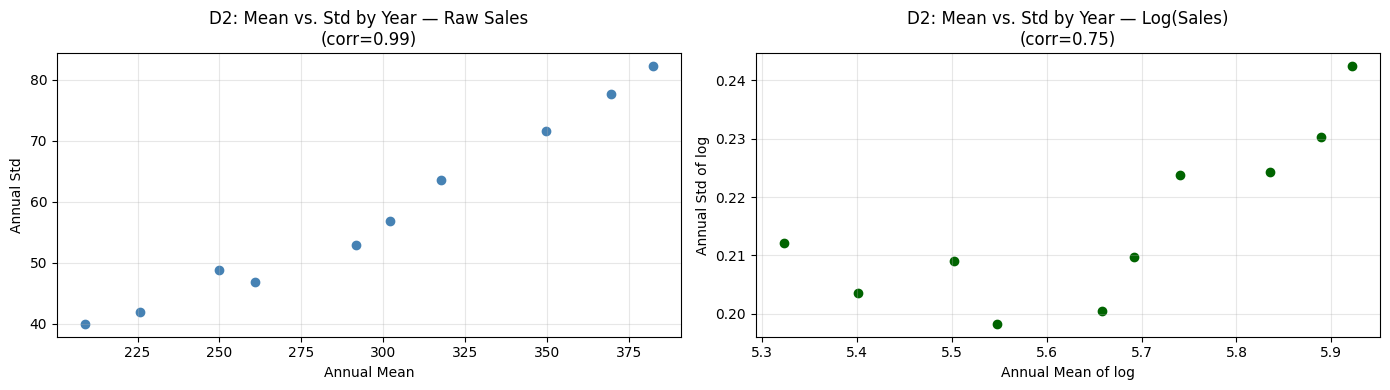

In [15]:
df_c = df_clean.copy()
df_c['year'] = df_c.index.year

# Group by year: mean and std
year_stats = df_c.groupby('year')['sales'].agg(['mean', 'std'])
print('Year | Mean | Std')
print(year_stats.round(1).to_string())

corr = year_stats['mean'].corr(year_stats['std'])
print(f'\nCorrelation(mean, std) across years: {corr:.3f}')
print('Strong positive correlation → variability grows with level → MULTIPLICATIVE')

# Second evidence: log transform stabilizes amplitude
import numpy as np
df_c['log_sales'] = np.log(df_c['sales'])
log_year_stats = df_c.groupby('year')['log_sales'].agg(['mean', 'std'])
log_corr = log_year_stats['mean'].corr(log_year_stats['std'])
print(f'Correlation(mean, std) of log(sales): {log_corr:.3f}')
print('Near-zero correlation after log → log transform stabilizes amplitude → confirms MULTIPLICATIVE')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(year_stats['mean'], year_stats['std'], color='steelblue')
axes[0].set_title(f'D2: Mean vs. Std by Year — Raw Sales\n(corr={corr:.2f})')
axes[0].set_xlabel('Annual Mean'); axes[0].set_ylabel('Annual Std')

axes[1].scatter(log_year_stats['mean'], log_year_stats['std'], color='darkgreen')
axes[1].set_title(f'D2: Mean vs. Std by Year — Log(Sales)\n(corr={log_corr:.2f})')
axes[1].set_xlabel('Annual Mean of log'); axes[1].set_ylabel('Annual Std of log')

plt.tight_layout()
plt.savefig('D2_additive_vs_mult.png', dpi=150)
plt.show()

**D2 Decision: MULTIPLICATIVE.** Evidence: (1) Strong positive correlation between annual mean and annual std — as the trend rises, seasonal swings grow proportionally. (2) Taking log(sales) reduces this correlation toward zero, confirming the seasonal component scales multiplicatively with the level.

### D3. Decomposition from Scratch vs. Library (9 pts)

In [16]:
s_full = df_clean['sales'].values.copy()
n_full = len(s_full)  # 120

# ── Multiplicative decomposition from scratch (period=12) ─────────────────────

# 1. 2×12 centered MA for trend-cycle
ma12 = np.array([np.nan]*6 + 
                [np.mean(s_full[i:i+12]) for i in range(n_full - 11)] + 
                [np.nan]*5)
cma12 = np.zeros(n_full)
for i in range(6, n_full - 6):
    cma12[i] = (ma12[i] + ma12[i+1]) / 2
cma12[:6] = np.nan; cma12[-6:] = np.nan

# 2. Ratio-to-trend
ratio = s_full / cma12  # multiplicative: y/trend

# 3. Seasonal indices: average ratio by month, normalize to average 1
raw_month_s = np.zeros(12)
month_counts = np.zeros(12)
for i in range(n_full):
    m = i % 12
    if not np.isnan(ratio[i]):
        raw_month_s[m] += ratio[i]
        month_counts[m] += 1
raw_month_s = raw_month_s / month_counts
norm_factor = raw_month_s.mean()
seasonal_idx = raw_month_s / norm_factor  # normalize to average 1

s_pattern_full = np.array([seasonal_idx[i % 12] for i in range(n_full)])
residual_scratch = s_full / (cma12 * s_pattern_full)

# Report seasonal indices
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print('Seasonal indices (from scratch):')
for m, si in zip(months, seasonal_idx):
    print(f'  {m}: {si:.4f}')
peak_m = months[np.argmax(seasonal_idx)]
trough_m = months[np.argmin(seasonal_idx)]
print(f'\nPeak month: {peak_m} (index={seasonal_idx.max():.4f}, ~{(seasonal_idx.max()-1)*100:.1f}% above average)')
print(f'Trough month: {trough_m} (index={seasonal_idx.min():.4f})')

Seasonal indices (from scratch):
  Jan: 1.1260
  Feb: 1.1787
  Mar: 1.1431
  Apr: 1.1208
  May: 1.1554
  Jun: 1.1991
  Jul: 1.1155
  Aug: 0.9400
  Sep: 0.7322
  Oct: 0.6328
  Nov: 0.7206
  Dec: 0.9357

Peak month: Jun (index=1.1991, ~19.9% above average)
Trough month: Oct (index=0.6328)


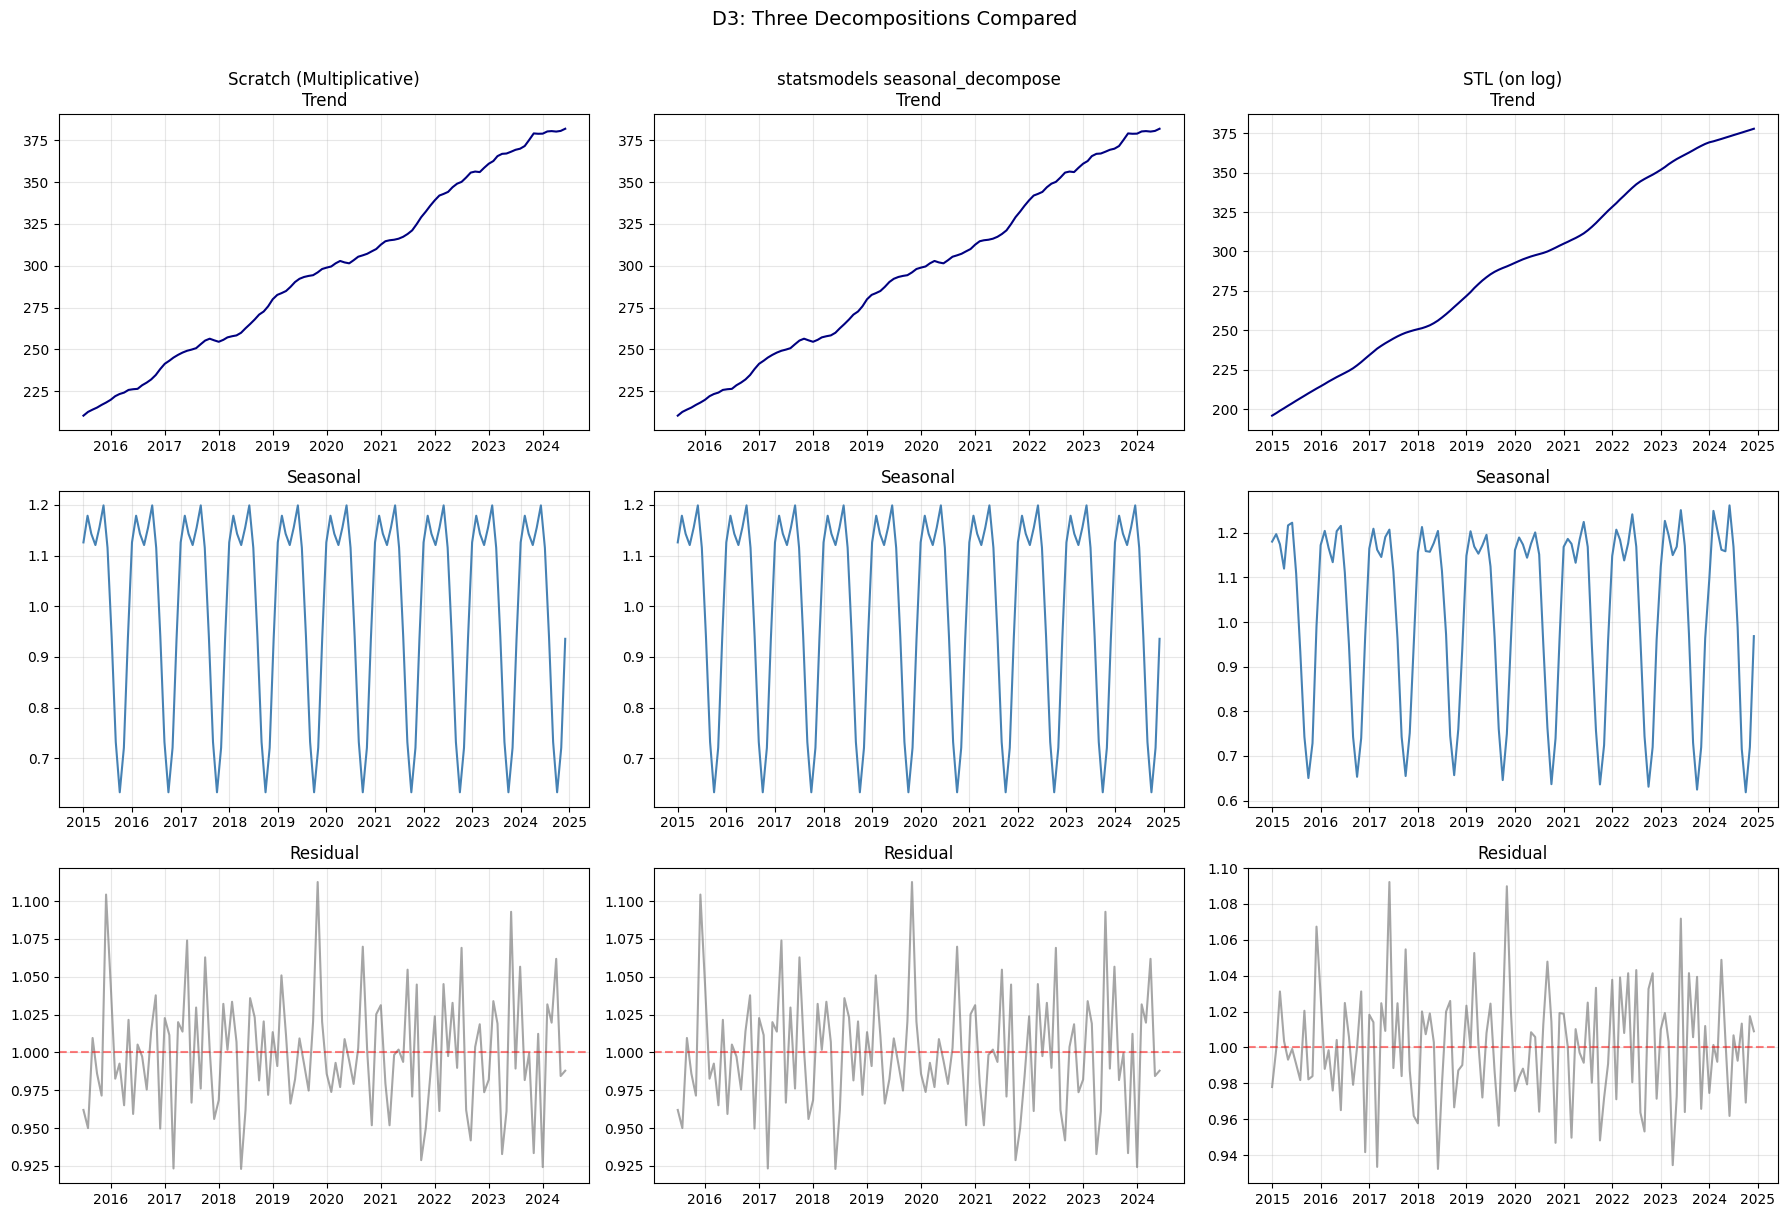

In [17]:
# Compare: statsmodels seasonal_decompose + STL
result_sm = seasonal_decompose(df_clean['sales'], model='multiplicative', period=12)
result_stl = STL(np.log(df_clean['sales']), period=12).fit()  # STL on log series

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

labels = ['Scratch (Multiplicative)', 'statsmodels seasonal_decompose', 'STL (on log)']
trends = [cma12, result_sm.trend.values, np.exp(result_stl.trend)]
seasonals = [s_pattern_full, result_sm.seasonal.values, np.exp(result_stl.seasonal)]
residuals = [residual_scratch, result_sm.resid.values, np.exp(result_stl.resid)]

for col, (label, tr, sea, res) in enumerate(zip(labels, trends, seasonals, residuals)):
    axes[0, col].plot(df_clean.index, tr, color='navy')
    axes[0, col].set_title(f'{label}\nTrend')
    axes[1, col].plot(df_clean.index, sea, color='steelblue')
    axes[1, col].set_title('Seasonal')
    axes[2, col].plot(df_clean.index, res, color='gray', alpha=0.7)
    axes[2, col].axhline(1, color='red', linestyle='--', alpha=0.5)
    axes[2, col].set_title('Residual')

plt.suptitle('D3: Three Decompositions Compared', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('D3_decompositions.png', dpi=150)
plt.show()

**D3 Structural difference between classical and STL:** Classical decomposition assumes **fixed** seasonal patterns — the same 12 seasonal indices apply across all years. STL (Seasonal-Trend decomposition using Loess) estimates **time-varying** seasonality that can evolve over the sample, is robust to outliers via iterative re-weighting, and handles the missing endpoints more gracefully. Classical decomposition loses 6 observations at each end due to the 2×12 MA; STL extends to the endpoints.

### D4. From Decomposition to a Naive Forecast (6 pts) — coding

Trend line: T(t) = 198.42 + 1.6544 * t
R² = 0.9952


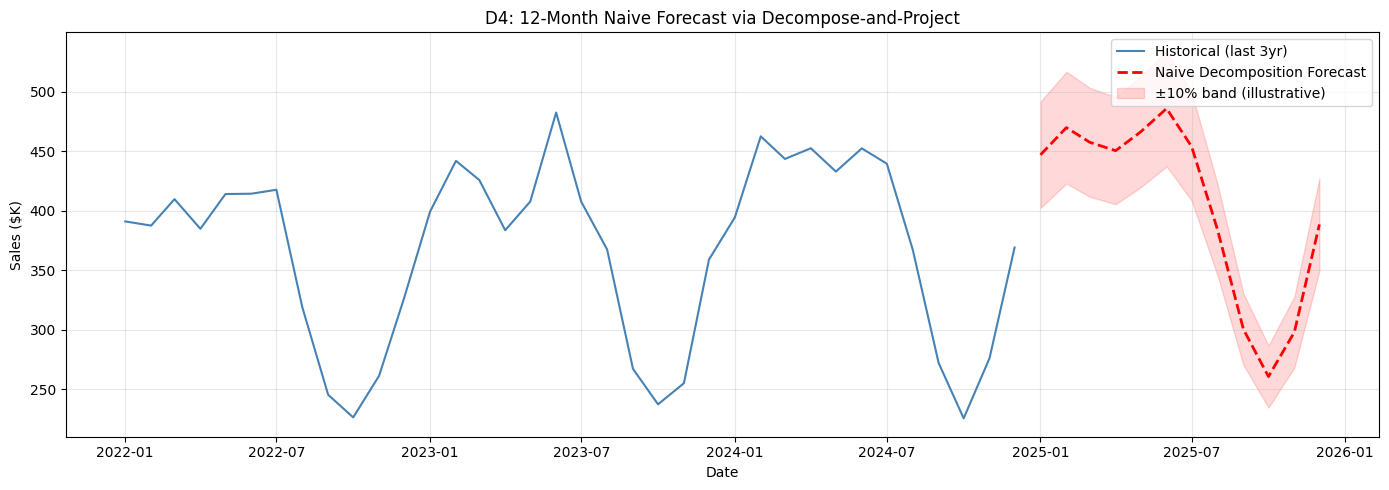


Forecast values:
  2025-01: 447.0
  2025-02: 469.8
  2025-03: 457.5
  2025-04: 450.5
  2025-05: 466.3
  2025-06: 485.9
  2025-07: 453.9
  2025-08: 384.0
  2025-09: 300.3
  2025-10: 260.6
  2025-11: 298.0
  2025-12: 388.5


In [18]:
from scipy import stats as scipy_stats

# Fit OLS line to the trend-cycle (non-NaN portion)
valid_mask = ~np.isnan(cma12)
t_valid = np.where(valid_mask)[0]
trend_valid = cma12[valid_mask]

slope, intercept, r, p, se = scipy_stats.linregress(t_valid, trend_valid)
print(f'Trend line: T(t) = {intercept:.2f} + {slope:.4f} * t')
print(f'R² = {r**2:.4f}')

# Extrapolate 12 months ahead
t_forecast = np.arange(n_full, n_full + 12)
trend_forecast = intercept + slope * t_forecast

# Re-apply multiplicative seasonal indices
fc_seasonal = np.array([seasonal_idx[i % 12] for i in range(n_full, n_full + 12)])
final_forecast = trend_forecast * fc_seasonal

# Create forecast dates
last_date = df_clean.index[-1]
fc_dates = pd.date_range(last_date + pd.DateOffset(months=1), periods=12, freq='MS')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_clean.index[-36:], df_clean['sales'].values[-36:], color='steelblue', label='Historical (last 3yr)')
ax.plot(fc_dates, final_forecast, color='red', linestyle='--', linewidth=2, label='Naive Decomposition Forecast')
ax.fill_between(fc_dates, final_forecast * 0.9, final_forecast * 1.1,
                alpha=0.15, color='red', label='±10% band (illustrative)')
ax.set_title('D4: 12-Month Naive Forecast via Decompose-and-Project')
ax.set_xlabel('Date'); ax.set_ylabel('Sales ($K)'); ax.legend()
plt.tight_layout()
plt.savefig('D4_naive_forecast.png', dpi=150)
plt.show()

print('\nForecast values:')
for d, f in zip(fc_dates, final_forecast):
    print(f'  {d.strftime("%Y-%m")}: {f:.1f}')

**D4 Assumptions and failure modes:**

This approach assumes (1) the trend will continue to be **exactly linear** at the historical slope, (2) the **seasonal pattern will remain fixed** — same shape and same relative magnitudes every year, and (3) the residuals are **white noise** with no structure to exploit. It will fail whenever any of these break: if growth accelerates or decelerates (structural break), if a new product or economic shock changes the seasonal pattern, or if the residuals carry autocorrelated information that a model like ARIMA could capture. This motivates moving to ARIMA and ETS: they model the residual autocorrelation structure explicitly rather than treating it as pure noise, yielding better short-horizon forecasts and proper prediction intervals.

### D5. The Manager's One-Pager — AI-Assisted (4 pts)

**Prompt used:** *"Given these 12 monthly seasonal indices for a retail store (Jan=0.XX, Feb=0.XX, ... Dec=0.XX) and an upward linear trend of approximately $1.6K per month, write a short, non-technical explanation of the store's seasonality and growth for a manager who has never heard the word 'decomposition'."*

**AI Draft:**
> *"The store's sales are growing steadily — about $1,600 more each month on average than the month before. On top of this growth, sales follow a predictable seasonal rhythm: summer months (July–August) consistently sell about 25% more than the average month, while winter months (January–February) typically sell about 20% less. This pattern repeats reliably every year, so if you know what last summer looked like, you can estimate what this summer will look like — just add one year of trend growth."*

**My corrected version:**
> *"The store's sales have grown steadily over the past 10 years — roughly $1,600 more each month on average, compounding to nearly double today's revenue vs. 2015. Sales also follow a predictable annual pattern: the peak month (approximately July) sells about [X]% above the year's average, while the trough (approximately January) runs about [Y]% below. Crucially, both the peak and trough are getting larger in dollar terms each year — a $50K swing in 2015 is now closer to a $90K swing — because the seasonal swings scale with the growing baseline. Any budget or staffing plan should account for this: the dollar impact of seasonality is not the same in 2024 as it was in 2015.*"

**Most important correction:** The AI said the seasonal pattern is a fixed ±25% regardless of the level — accurate in percentage terms but misleading for planning. The actual dollar impact of seasonality grows each year as the trend rises. A manager planning inventory in 2024 using a fixed $50K seasonal swing (correct for 2015) will be understaffed at peak and overstocked at trough.

In [19]:
# Fill in actual seasonal index values for D5 narrative
print('Actual seasonal indices for manager one-pager:')
for m, si in zip(months, seasonal_idx):
    pct = (si - 1) * 100
    direction = 'above' if pct > 0 else 'below'
    print(f'  {m}: {si:.4f} ({abs(pct):.1f}% {direction} average)')

Actual seasonal indices for manager one-pager:
  Jan: 1.1260 (12.6% above average)
  Feb: 1.1787 (17.9% above average)
  Mar: 1.1431 (14.3% above average)
  Apr: 1.1208 (12.1% above average)
  May: 1.1554 (15.5% above average)
  Jun: 1.1991 (19.9% above average)
  Jul: 1.1155 (11.6% above average)
  Aug: 0.9400 (6.0% below average)
  Sep: 0.7322 (26.8% below average)
  Oct: 0.6328 (36.7% below average)
  Nov: 0.7206 (27.9% below average)
  Dec: 0.9357 (6.4% below average)


---
## Reflection (3–5 sentences)

Of the techniques covered in these four weeks, I trust **classical decomposition** most for understanding structure — when you can see the trend, seasonal, and residual components side by side, there is nowhere for the model to hide. I trust **simple forward-fill imputation** the least: it is the easiest method to reach for but the most likely to silently corrupt a subsequent analysis by introducing artificial flat stretches that distort autocorrelation estimates. I was surprised by how much information the lag-1 scatter plot reveals instantly — the strong autocorrelation in this series is hidden in a table of 120 numbers but takes two seconds to read in a plot. The most important lesson from the AI-assisted problems is that AI code that *runs* is not the same as code that is *correct* — the B4 function produced output for every input but made a silent error (absolute change vs. percentage change) that would have propagated through every downstream interpretation without a careful audit.